# Assignment 2 — Shallow Models Training, Validation, and Tuning

**Neera Patel**  
AI & Machine Learning Foundations  

GitHub Repository: https://github.com/neerapatel5/ML-fundamentals-2026.git

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# =========================
# Metrics
# =========================
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from skopt import BayesSearchCV
import warnings
warnings.filterwarnings("ignore")

# Loading the Dataset + EDA

For this assignment, I am using the `hour.csv` dataset from the UCI Bike Sharing Dataset. The goal is to predict hourly bike rental demand (`cnt`) using environmental, weather, and temporal variables.

Since this is ultimately a regression problem, the first thing I want to understand is how the target variable behaves before touching any models. A lot of the ML foundations lectures emphasized that good modeling decisions usually start with understanding the structure of the data itself rather than immediately jumping into training.

In [4]:
df = pd.read_csv("hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Before exploring relationships between variables, I want to inspect the overall structure of the dataset:

- number of observations
- feature types
- missing values
- whether any columns immediately look suspicious or redundant

One thing I learned from Assignment 1 is that catching leakage or redundant variables early can save a lot of downstream issues later in the pipeline.

In [5]:
## examine dataset
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(17379, 17)

Column Names:
Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

Data Types:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


In [6]:
## check for missing values
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Even though there are no explicit missing values, I still want to stay cautious about “hidden” data quality issues.

In [7]:
df.describe

<bound method NDFrame.describe of        instant      dteday  season  yr  mnth  hr  holiday  weekday  \
0            1  2011-01-01       1   0     1   0        0        6   
1            2  2011-01-01       1   0     1   1        0        6   
2            3  2011-01-01       1   0     1   2        0        6   
3            4  2011-01-01       1   0     1   3        0        6   
4            5  2011-01-01       1   0     1   4        0        6   
...        ...         ...     ...  ..   ...  ..      ...      ...   
17374    17375  2012-12-31       1   1    12  19        0        1   
17375    17376  2012-12-31       1   1    12  20        0        1   
17376    17377  2012-12-31       1   1    12  21        0        1   
17377    17378  2012-12-31       1   1    12  22        0        1   
17378    17379  2012-12-31       1   1    12  23        0        1   

       workingday  weathersit  temp   atemp   hum  windspeed  casual  \
0               0           1  0.24  0.2879  0.81    

- `cnt` appears highly variable, which definitely makes sense because bike demand probably changes dramatically depending on hour, weather, and season.
- `casual` and `registered` are likely leakage-related variables because they directly sum into the target variable `cnt`.

From a predictive modeling perspective, including features that are mathematically tied to the target would artificially inflate performance and affect real-world generalization.

### Exploring the Target Variable (`cnt`)

The target variable is the hourly count of rented bikes.

Before building regression models, I want to examine:
- distribution shape
- skewness
- possible outliers
- whether transformations may eventually help performance

If the target distribution is heavily skewed or contains extreme values, some models may struggle more than others.

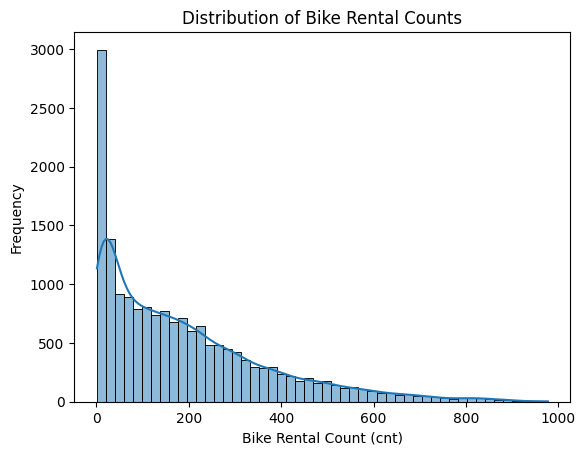

Skewness of cnt:
1.2774116037490577


In [8]:
sns.histplot(df["cnt"], bins=50, kde=True)

plt.title("Distribution of Bike Rental Counts")
plt.xlabel("Bike Rental Count (cnt)")
plt.ylabel("Frequency")

plt.show()

print("Skewness of cnt:")
print(df["cnt"].skew())

The distribution is clearly right-skewed, meaning there are many lower-rental hours and fewer extremely high-demand hours, which adds up. Most hours during the day probably experience moderate demand, while commuting periods or ideal weather conditions create those sharp spikes.

The skewness is important because:
- Linear Regression may struggle with nonlinear spikes in demand
- Tree-based models like Random Forest and Gradient Boosting may adapt better to these irregular patterns
- Residual variance may increase at higher prediction values, which could later indicate heteroskedasticity

### Numerical Feature Relationships

Before feature engineering, I also want to examine relationships between continuous variables. This is especially important because highly correlated predictors can reduce interpretability or destabilize linear models. Tree-based models are usually more tolerant of multicollinearity, but linear models are much more sensitive to it.

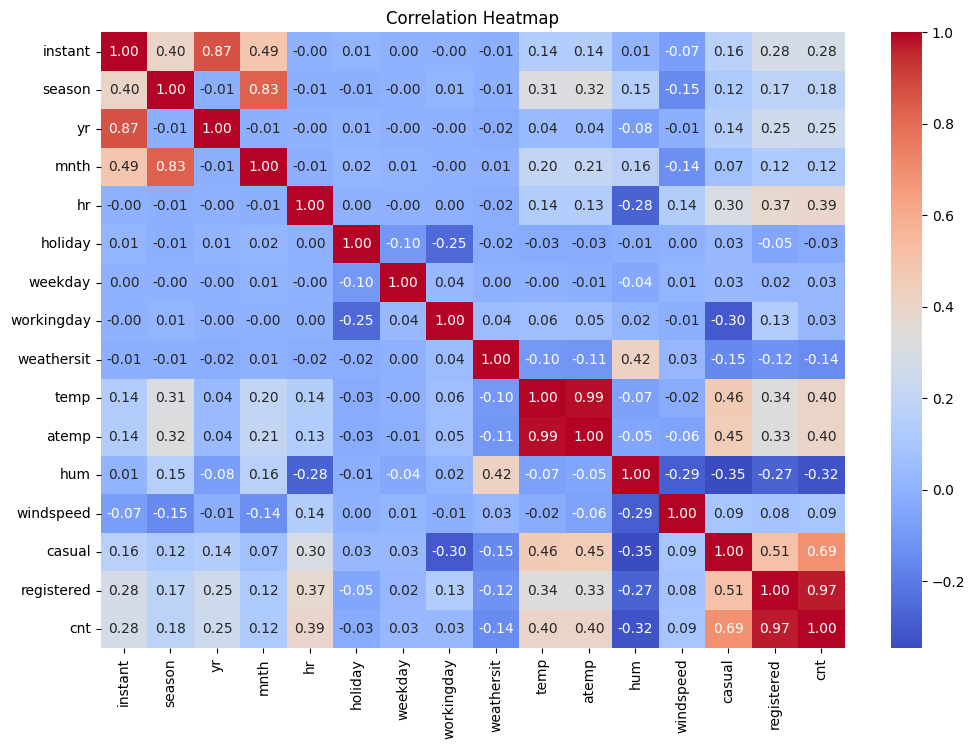

In [9]:
numeric_cols = df.select_dtypes(include=np.number)
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

A few relationships stand out immediately. `registered` (~0.97) and `casual` (~0.69) are both highly correlated with `cnt`, which makes sense since `cnt = casual + registered`. Because of this, both columns create target leakage and will be removed before modeling.

`temp` and `atemp` are also almost perfectly correlated (~0.99), so keeping both may introduce unnecessary redundancy. Meanwhile, variables like `hr`, `temp`, and `hum` show more moderate relationships with `cnt`, suggesting that nonlinear patterns and feature interactions may matter more than simple linear correlation alone.

Applying what I have learned in class, correlation alone does not necessarily measure predictive usefulness, especially for nonlinear models. Some variables may appear weak in isolation but become highly important once interactions and nonlinear splits are introduced in models like Random Forests or Gradient Boosting.

### Temporal Patterns (Hour of Day)

One of the most important variables in this dataset is likely `hr`. Naturally, human behavior tends to follow cyclical patterns rather than purely linear ones. Commute hours, lunch breaks, and nighttime inactivity should all create predictable fluctuations in bike rentals.

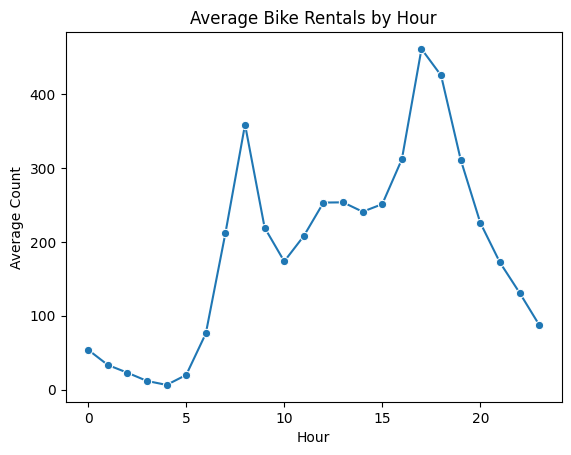

In [10]:
hourly_avg = df.groupby("hr")["cnt"].mean()

sns.lineplot(
    x=hourly_avg.index,
    y=hourly_avg.values,
    marker="o"
)

plt.title("Average Bike Rentals by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Count")

plt.show()

The pattern is extremely intuitive, showing strong peaks during commuting hours and lower activity overnight. This suggests that temporal structure is going to be very important for prediction performance. It also reinforces why cyclical encoding is preferable over raw integer encoding for variables like `hr` and `weekday`.

### Weather and Environmental Effects

Since this is a transportation-related prediction problem, weather likely plays a major role in rental demand.
- warmer temperatures → more rentals
- extreme humidity → fewer rentals

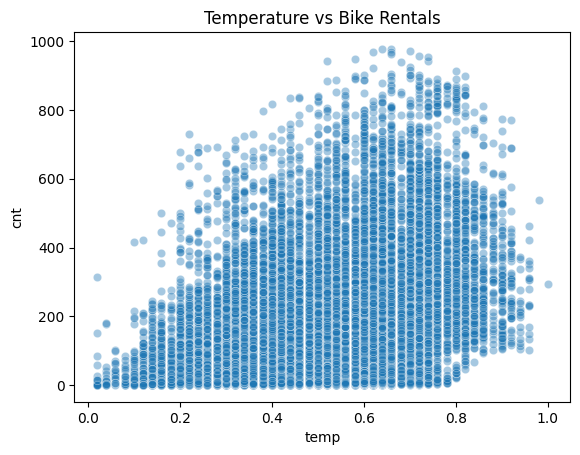

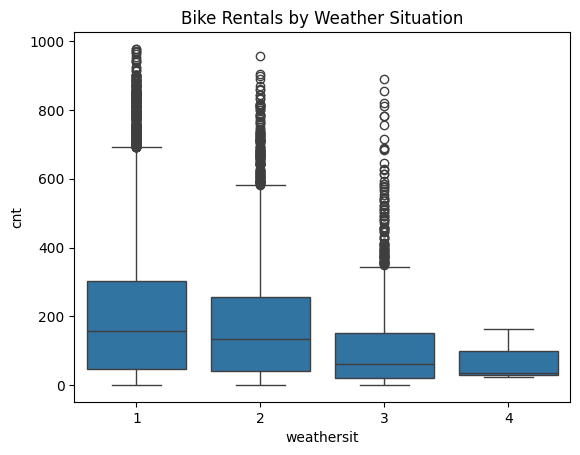

In [11]:
sns.scatterplot(
    data=df,
    x="temp",
    y="cnt",
    alpha=0.4
)
plt.title("Temperature vs Bike Rentals")
plt.show()

sns.boxplot(
    data=df,
    x="weathersit",
    y="cnt"
)
plt.title("Bike Rentals by Weather Situation")
plt.show()

Bike rentals generally increase as temperature rises, although the relationship is not perfectly linear. The weather condition boxplot also shows a clear decline in rentals during worse weather conditions, especially in categories 3 and 4. Together, these plots clearly show that environmental variables will play a meaningful role in prediction performance.

### Outliers and Suspicious Patterns

At this stage, I want to identify whether any observations appear extreme enough to distort modeling performance. I want to actually understand whether they reflect actual behavior or data errors before immediately just removing outliers. In transportation datasets, unusually high demand periods may actually contain important business information rather than noise.

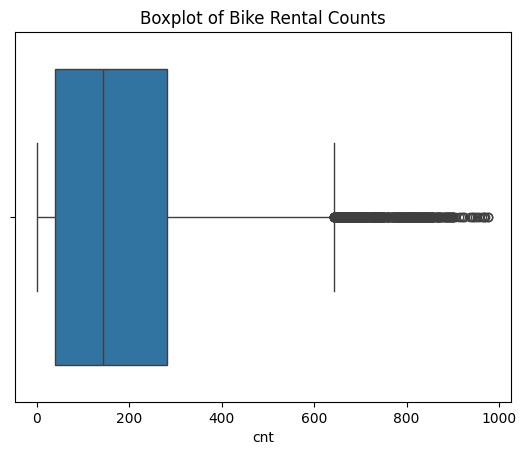

In [12]:
sns.boxplot(x=df["cnt"])
plt.title("Boxplot of Bike Rental Counts")
plt.show()

The boxplot shows several high-demand outliers, particularly above 600 rentals. That being said, these values likely represent real peak commuting or seasonal demand rather than data errors, so I do not plan to remove them as of right now. Since tree-based models are generally better equipped to handle outliers, keeping these observations may help the model better capture real-world spikes in bike usage.

### Planned Feature Removal

Based on the EDA, I plan to remove the following columns before modeling:
instant: identifier only
dteday: raw date column not directly useful in current form 
casual: leakage into target
registered: Leakage into target 

# Data Splitting
Since this dataset is time-based, I am using a random split with a fixed seed because the data covers repeated hourly patterns across two years, and I want all three sets to contain a realistic mix of seasons, hours, and weather conditions.

In [15]:
columns_drop = ["instant", "dteday", "casual", "registered"]

bike_model = df.drop(columns=columns_drop).copy()

# separate features from the prediction target
X = bike_model.drop(columns="cnt")
y = bike_model["cnt"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (17379, 12)
Target shape: (17379,)


In [16]:
# first split: 60% training data, 40% held out for validation/test
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=2026,
    shuffle=True
)

# second split: Split the 40% into 20% validation and 20% test

X_val, X_test, y_val, y_test = train_test_split(
    X_holdout,
    y_holdout,
    test_size=0.50,
    random_state=2026,
    shuffle=True
)

In [19]:
# check final split sizes to ensure they're right

split_summary = pd.DataFrame({
    "Set": ["Training", "Validation", "Test"],
    "Rows": [len(X_train), len(X_val), len(X_test)],
    "Percent of Total": [
        len(X_train) / len(df) * 100,
        len(X_val) / len(df) * 100,
        len(X_test) / len(df) * 100
    ],
    "Target Mean": [
        y_train.mean(),
        y_val.mean(),
        y_test.mean()
    ],
    "Target Std": [
        y_train.std(),
        y_val.std(),
        y_test.std()
    ]
})

split_summary

,Set,Rows,Percent of Total,Target Mean,Target Std
0,Training,10427,59.997698,188.571497,180.004924
1,Validation,3476,20.001151,183.850403,180.432694
2,Test,3476,20.001151,197.750288,186.178722


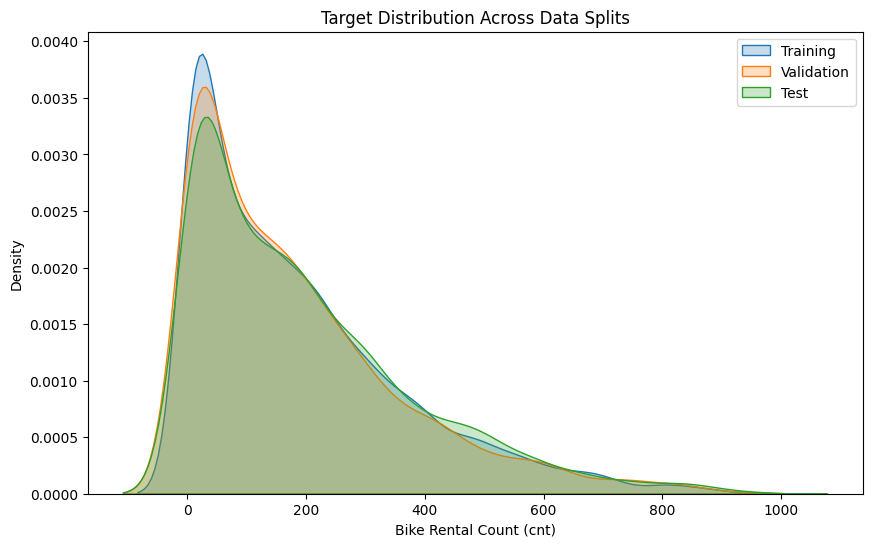

In [21]:
# check that the target distribution is reasonably similar across splits
plt.figure(figsize=(10, 6))

sns.kdeplot(y_train, label="Training", fill=True, alpha=0.25)
sns.kdeplot(y_val, label="Validation", fill=True, alpha=0.25)
sns.kdeplot(y_test, label="Test", fill=True, alpha=0.25)

plt.title("Target Distribution Across Data Splits")
plt.xlabel("Bike Rental Count (cnt)")
plt.ylabel("Density")
plt.legend()
plt.show()

The final split follows the required 60/20/20 structure. The distributions are not identical, but they are close enough to support fair validation and testing. Most importantly, this split happens before scaling, encoding, cyclical transformations, or interaction terms, so the validation and test sets remain genuinely unseen.

I used a 60/20/20 split to balance training size with reliable evaluation. The training set is large enough for the models to learn meaningful patterns, while keeping separate validation and test sets allows me to tune hyperparameters and evaluate final generalization performance without reusing the same data multiple times.